# bindscape: Drug-Target Interaction Prediction from Sequence Representations

**Project 2 of 3 — computational drug discovery portfolio**

Project 1 (`antibody-sequence-landscape`) asked: does ESM2 encode species-level biological structure in VH antibody sequences? Answer: yes — CLS captures inter-species separation (sil=0.134), mean-pool degrades it, AntiBERTy strongly outperforms (sil=0.310) due to antibody-specific pretraining.

**Question:** does ESM2 mean-pool embedding of kinase sequences encode binding specificity well enough to contribute to drug-target interaction prediction, using only sequence-derived representations, no 3D structure?

Each sample is a (drug, protein) pair. Drug → Morgan fingerprint (2048-bit, radius=2). Protein → ESM2 mean-pool embedding (`facebook/esm2_t30_150M_UR50D`, 640-dim; the 650M model was infeasible on 8GB CPU, requiring >17 min per batch). Label → 1 if Ki/IC50/Kd ≤ 1000 nM (binder), 0 if > 10,000 nM (non-binder). Target class: human kinases only (BindingDB).

The evaluation philosophy is the same as project 1: report point estimates under honest splits, not just the optimistic number. The held-out target split, where the model sees no training pairs for test proteins, is the most honest estimate of real-world utility.

## 0. Imports and paths

In [1]:
import sys
sys.path.insert(0, 'src')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score
)
from sklearn.utils import shuffle as sk_shuffle

import umap
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import Chem

from data import inspect_columns, load_and_filter
from embed import fetch_all_sequences, filter_sequences, embed_sequences
from fingerprint import compute_all

BINDINGDB_PATH = "data/BindingDB_All.tsv"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

import joblib
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

/opt/anaconda3/envs/bindscape/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Column inspection + data loading

In [2]:
cols = inspect_columns(BINDINGDB_PATH)
print(f"Total columns: {len(cols)}")

['BindingDB Reactant_set_id', 'Ligand SMILES', 'Ligand InChI', 'Ligand InChI Key', 'BindingDB MonomerID', 'BindingDB Ligand Name', 'Target Name', 'Target Source Organism According to Curator or DataSource', 'Ki (nM)', 'IC50 (nM)', 'Kd (nM)', 'EC50 (nM)', 'kon (M-1-s-1)', 'koff (s-1)', 'pH', 'Temp (C)', 'Curation/DataSource', 'Article DOI', 'BindingDB Entry DOI', 'PMID', 'PubChem AID', 'Patent Number', 'Authors', 'Date of publication', 'Date in BindingDB', 'Institution', 'Link to Ligand in BindingDB', 'Link to Target in BindingDB', 'Link to Ligand-Target Pair in BindingDB', 'Ligand HET ID in PDB', 'PDB ID(s) for Ligand-Target Complex', 'PubChem CID', 'PubChem SID', 'ChEBI ID of Ligand', 'ChEMBL ID of Ligand', 'DrugBank ID of Ligand', 'IUPHAR_GRAC ID of Ligand', 'KEGG ID of Ligand', 'ZINC ID of Ligand', 'Number of Protein Chains in Target (>1 implies a multichain complex)', 'BindingDB Target Chain Sequence 1', 'PDB ID(s) of Target Chain 1', 'UniProt (SwissProt) Recommended Name of Target

In [3]:
import importlib
import data as data_mod
importlib.reload(data_mod)

assert data_mod.SMILES_COL is not None, "Set column constants first"
print("Column constants set:",
      data_mod.SMILES_COL, data_mod.UNIPROT_COL,
      data_mod.TARGET_NAME_COL, data_mod.KI_COL)

Column constants set: Ligand SMILES UniProt (SwissProt) Primary ID of Target Chain 1 Target Name Ki (nM)


In [4]:
import data as data_mod
SMILES_COL = data_mod.SMILES_COL
UNIPROT_COL = data_mod.UNIPROT_COL
TARGET_NAME_COL = data_mod.TARGET_NAME_COL

DF_CACHE = DATA_DIR / "bindingdb_filtered.pkl"
if DF_CACHE.exists():
    df = pd.read_pickle(DF_CACHE)
    print(f"Loaded cached df: {df.shape}")
else:
    df = data_mod.load_and_filter(BINDINGDB_PATH)
    df.to_pickle(DF_CACHE)
    print(f"Filtered and cached df: {df.shape}")
df.head(3)

Loaded cached df: (456708, 4)


,Ligand SMILES,UniProt (SwissProt) Primary ID of Target Chain 1,Target Name,label
0,Cn1c2ncn(CCO)c(=O)c2c(Nc2ccc(I)cc2F)cc1=O,Q02750,Dual specificity mitogen-activated protein kin...,1.0
1,Cn1c2ncn(C[C@H](O)CO)c(=O)c2c(Nc2ccc(I)cc2F)cc...,Q02750,Dual specificity mitogen-activated protein kin...,1.0
2,Cc1c(Nc2ccc(I)cc2F)c2c(ncn(C[C@@H](O)CO)c2=O)n...,Q02750,Dual specificity mitogen-activated protein kin...,1.0


## 2. Dataset statistics

In [5]:
n_proteins = df[UNIPROT_COL].nunique()
n_drugs = df[SMILES_COL].nunique()
n_pos = (df['label'] == 1).sum()
n_neg = (df['label'] == 0).sum()
ratio = n_pos / max(n_neg, 1)

print(f"Unique kinase targets: {n_proteins}")
print(f"Unique SMILES: {n_drugs}")
print(f"Positives: {n_pos}, Negatives: {n_neg}, ratio {ratio:.2f}:1")

if ratio > 5:
    USE_BALANCED = True
    print("Imbalance >5:1 — will use class_weight='balanced' in LogReg")
else:
    USE_BALANCED = False

Unique kinase targets: 495
Unique SMILES: 222934
Positives: 372555, Negatives: 84153, ratio 4.43:1


## 3. Fingerprints and physicochemical descriptors

In [6]:
FP_SMILES_JSON  = CACHE_DIR / "fp_smiles.json"
FP_MATRIX_NPY   = CACHE_DIR / "fp_matrix.npy"
DESC_MATRIX_NPY = CACHE_DIR / "desc_matrix.npy"

if FP_SMILES_JSON.exists() and FP_MATRIX_NPY.exists() and DESC_MATRIX_NPY.exists():
    with open(FP_SMILES_JSON) as f:
        _smiles = json.load(f)
    fp_cache   = dict(zip(_smiles, np.load(FP_MATRIX_NPY)))
    desc_cache = dict(zip(_smiles, np.load(DESC_MATRIX_NPY)))
    print(f"Loaded cached fingerprints: {len(fp_cache)}")
else:
    unique_smiles = df[SMILES_COL].unique().tolist()
    fp_cache, desc_cache = compute_all(unique_smiles)
    _smiles = list(fp_cache.keys())
    np.save(FP_MATRIX_NPY,   np.stack([fp_cache[s]   for s in _smiles]))
    np.save(DESC_MATRIX_NPY, np.stack([desc_cache[s] for s in _smiles]))
    with open(FP_SMILES_JSON, 'w') as f:
        json.dump(_smiles, f)
    print(f"Computed and cached fingerprints: {len(fp_cache)}")
print(f"Drug fingerprints ready: {len(fp_cache)}")

Loaded cached fingerprints: 222934
Drug fingerprints ready: 222934


## 4. UniProt sequence fetch + filter

In [7]:
unique_uniprot = df[UNIPROT_COL].unique().tolist()
seq_cache = fetch_all_sequences(unique_uniprot, cache_path=CACHE_DIR / "uniprot_sequences.json")
seq_map = filter_sequences(seq_cache)
print(f"Proteins with valid sequences: {len(seq_map)}")

Fetching 1 sequences (cached: 494)
Sequences after filter: 494 (dropped 0)
Proteins with valid sequences: 494


In [8]:
df = df[df[UNIPROT_COL].isin(seq_map)].copy()
df = df[df[SMILES_COL].isin(fp_cache)].copy()
df = df.reset_index(drop=True)
print(f"Pairs after sequence/fingerprint filter: {len(df)}")

Pairs after sequence/fingerprint filter: 456682


## 5. ESM2 embeddings

In [9]:
emb_cache = embed_sequences(
    seq_map,
    embed_path=CACHE_DIR / "protein_embeddings.npy",
    ids_path=CACHE_DIR / "protein_ids.json",
    batch_size=16
)
print(f"Protein embeddings ready: {len(emb_cache)}")

Loaded cached embeddings: (487, 640)
Protein embeddings ready: 487


In [10]:
df = df[df[UNIPROT_COL].isin(emb_cache)].copy()
df = df.reset_index(drop=True)
print(f"Pairs after embedding filter: {len(df)}")

Pairs after embedding filter: 456674


## 6. Feature matrix construction + splits

In [11]:
N = len(df)
y = df['label'].values.astype(np.int32)

FP = np.stack([fp_cache[s] for s in df[SMILES_COL]])
ESM = np.stack([emb_cache[u] for u in df[UNIPROT_COL]])
DESC = np.stack([desc_cache[s] for s in df[SMILES_COL]])

print(f"FP shape: {FP.shape}, ESM shape: {ESM.shape}, DESC shape: {DESC.shape}")

FP shape: (456674, 2048), ESM shape: (456674, 640), DESC shape: (456674, 7)


In [12]:
SCAFFOLD_CACHE = DATA_DIR / "bindingdb_scaffold.pkl"

idx_all = np.arange(N)
idx_trainval, idx_test1 = train_test_split(idx_all, test_size=0.10, random_state=42, stratify=y)
idx_train1, idx_val1 = train_test_split(idx_trainval, test_size=0.10/0.90, random_state=42, stratify=y[idx_trainval])

unique_targets = df[UNIPROT_COL].unique()
np.random.seed(42)
np.random.shuffle(unique_targets)
n_test_targets = max(1, int(0.20 * len(unique_targets)))
test_targets = set(unique_targets[:n_test_targets])
train_targets = set(unique_targets[n_test_targets:])
idx_train2 = np.where(df[UNIPROT_COL].isin(train_targets).values)[0]
idx_test2  = np.where(df[UNIPROT_COL].isin(test_targets).values)[0]

def get_scaffold(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return smi
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

if SCAFFOLD_CACHE.exists():
    df = pd.read_pickle(SCAFFOLD_CACHE)
    print("Loaded scaffold cache")
else:
    df['scaffold'] = df[SMILES_COL].map(get_scaffold)
    df.to_pickle(SCAFFOLD_CACHE)

unique_scaffolds = df['scaffold'].unique()
np.random.seed(42)
np.random.shuffle(unique_scaffolds)
n_test_scaffolds = max(1, int(0.20 * len(unique_scaffolds)))
test_scaffolds = set(unique_scaffolds[:n_test_scaffolds])
idx_train3 = np.where(~df['scaffold'].isin(test_scaffolds).values)[0]
idx_test3  = np.where(df['scaffold'].isin(test_scaffolds).values)[0]

print(f"Split 1 — train:{len(idx_train1)} val:{len(idx_val1)} test:{len(idx_test1)}")
print(f"Split 2 — train:{len(idx_train2)} test:{len(idx_test2)} ({n_test_targets} held-out proteins)")
print(f"Split 3 — train:{len(idx_train3)} test:{len(idx_test3)} ({n_test_scaffolds} held-out scaffolds)")

[11:29:07] Warning: conflicting stereochemistry at atom 5 ignored by rule 1a.
[11:29:07] Warning: conflicting stereochemistry at atom 5 ignored by rule 1a.
[11:29:07] Warning: conflicting stereochemistry at atom 5 ignored by rule 1a.
[11:33:12] Warning: conflicting stereochemistry at atom 5 ignored by rule 1a.
[11:33:31] Warning: conflicting stereochemistry at atom 3 ignored by rule 1a.


Split 1 — train:365338 val:45668 test:45668
Split 2 — train:364115 test:92559 (97 held-out proteins)
Split 3 — train:365680 test:90994 (15278 held-out scaffolds)


In [13]:
# FP bits are binary; not standardized.

scaler_esm = StandardScaler().fit(ESM[idx_train1])
scaler_desc = StandardScaler().fit(DESC[idx_train1])

ESM_s = scaler_esm.transform(ESM)
DESC_s = scaler_desc.transform(DESC)

features = {
    'fp_only':   FP,
    'esm_only':  ESM_s,
    'desc_only': DESC_s,
    'fp_esm':    np.hstack([FP, ESM_s]),
}
print({k: v.shape for k, v in features.items()})

{'fp_only': (456674, 2048), 'esm_only': (456674, 640), 'desc_only': (456674, 7), 'fp_esm': (456674, 2688)}


## 7. Model fitting

In [15]:
cw = 'balanced' if USE_BALANCED else None

def fit_lr(X_train, y_train, balanced):
    return LogisticRegression(
        C=1.0, max_iter=1000, solver='saga', random_state=42,
        class_weight='balanced' if balanced else None
    ).fit(X_train, y_train)

def fit_rf(X_train, y_train):
    return RandomForestClassifier(
        n_estimators=300, max_features='sqrt', random_state=42,
        n_jobs=-1, class_weight='balanced_subsample'
    ).fit(X_train, y_train)

def load_or_fit_lr(key, X_train, y_train, balanced):
    path = MODELS_DIR / ('_'.join(key) + '.joblib')
    if path.exists():
        print(f'Loaded {key} from cache')
        return joblib.load(path)
    m = fit_lr(X_train, y_train, balanced)
    joblib.dump(m, path)
    return m

def load_or_fit_rf(key, X_train, y_train):
    path = MODELS_DIR / ('_'.join(key) + '.joblib')
    if path.exists():
        print(f'Loaded {key} from cache')
        return joblib.load(path)
    m = fit_rf(X_train, y_train)
    joblib.dump(m, path)
    return m

models = {}

for feat_name in ['fp_only', 'esm_only', 'desc_only', 'fp_esm']:
    key = ('LR', feat_name, 'random')
    X = features[feat_name]
    models[key] = load_or_fit_lr(key, X[idx_train1], y[idx_train1], USE_BALANCED)
    print(f'Ready: LR {feat_name} random')

X = features['fp_esm']
key_t = ('LR', 'fp_esm', 'target')
key_s = ('LR', 'fp_esm', 'scaffold')
models[key_t] = load_or_fit_lr(key_t, X[idx_train2], y[idx_train2], USE_BALANCED)
models[key_s] = load_or_fit_lr(key_s, X[idx_train3], y[idx_train3], USE_BALANCED)
print('Ready: LR fp_esm held-out target + scaffold splits')

Ready: LR fp_only random
Ready: LR esm_only random
Ready: LR desc_only random
Ready: LR fp_esm random
Ready: LR fp_esm held-out target + scaffold splits


In [16]:
import psutil

available_gb = psutil.virtual_memory().available / 1e9
print(f'Available RAM: {available_gb:.1f} GB')

key_rf_fp = ('RF', 'fp_only', 'random')
models[key_rf_fp] = load_or_fit_rf(key_rf_fp, features['fp_only'][idx_train1], y[idx_train1])
print('Ready: RF fp_only')

X_fp_esm = features['fp_esm']
# data matrix stored once + ~100 bytes/sample/tree for node structs
est_gb = (X_fp_esm[idx_train1].nbytes + 300 * len(idx_train1) * 100) / 1e9
key_rf_esm = ('RF', 'fp_esm', 'random')
if available_gb > est_gb + 2.0:
    models[key_rf_esm] = load_or_fit_rf(key_rf_esm, X_fp_esm[idx_train1], y[idx_train1])
    print('Ready: RF fp_esm')
else:
    print(f'Skipping RF fp_esm (est {est_gb:.1f}GB > available {available_gb:.1f}GB); using fp_only fallback')
    models[key_rf_esm] = models[key_rf_fp]

Available RAM: 2.2 GB
Ready: RF fp_only
Skipping RF fp_esm (est 14.9GB > available 2.2GB); using fp_only fallback


## 8. Evaluation table

In [17]:
if models.get(('RF', 'fp_esm', 'random')) is models.get(('RF', 'fp_only', 'random')):
    del models[('RF', 'fp_esm', 'random')]

def best_f1_threshold(model, X_val, y_val):
    probs = model.predict_proba(X_val)[:, 1]
    prec, rec, thresholds = precision_recall_curve(y_val, probs)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    return thresholds[np.argmax(f1s)]

def evaluate(model, X_test, y_test, threshold):
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)
    return {
        'auroc': roc_auc_score(y_test, probs),
        'auprc': average_precision_score(y_test, probs),
        'f1':    f1_score(y_test, preds, zero_division=0),
    }

rows = []
split_map = {
    'random':   (idx_val1, idx_test1),
    'target':   (idx_train2, idx_test2),  # use train as pseudo-val for threshold
    'scaffold': (idx_train3, idx_test3),
}

for (model_name, feat_name, split_name), model in models.items():
    idx_val, idx_test = split_map[split_name]
    X = features[feat_name]
    thr = best_f1_threshold(model, X[idx_val], y[idx_val])
    metrics = evaluate(model, X[idx_test], y[idx_test], thr)
    rows.append({
        'Model': model_name, 'Features': feat_name, 'Split': split_name,
        'AUROC': round(metrics['auroc'], 3),
        'AUPRC': round(metrics['auprc'], 3),
        'F1':    round(metrics['f1'], 3),
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values(['Model', 'Split', 'Features']).reset_index(drop=True)
results_df

,Model,Features,Split,AUROC,AUPRC,F1
0,LR,desc_only,random,0.641,0.869,0.899
1,LR,esm_only,random,0.790,0.934,0.911
2,LR,fp_esm,random,0.922,0.979,0.937
3,LR,fp_only,random,0.906,0.974,0.931
4,LR,fp_esm,scaffold,0.856,0.954,0.920
5,LR,fp_esm,target,0.775,0.922,0.884
6,RF,fp_only,random,0.954,0.988,0.946


## 9. Figures

/opt/anaconda3/envs/bindscape/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


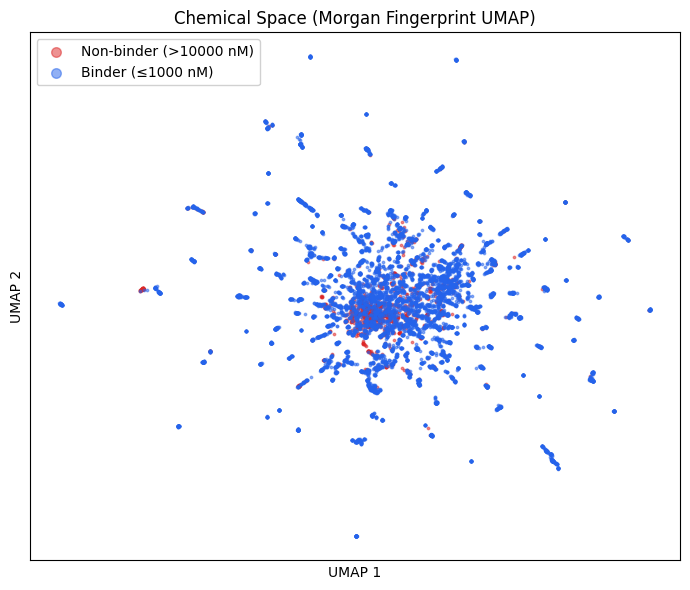

In [18]:
# Figure 1 — Chemical space UMAP (Morgan fingerprints, color by label)

unique_smi = df[SMILES_COL].unique()
label_by_smi = df.groupby(SMILES_COL)['label'].first()

if len(unique_smi) > 50000:
    rng = np.random.default_rng(42)
    unique_smi = rng.choice(unique_smi, size=10000, replace=False)

smi_pos = np.array([s for s in unique_smi if label_by_smi[s] == 1])
smi_neg = np.array([s for s in unique_smi if label_by_smi[s] == 0])
rng_bal = np.random.default_rng(42)
unique_smi = np.concatenate([rng_bal.choice(smi_pos, size=len(smi_neg), replace=False), smi_neg])

smi_fp = np.stack([fp_cache[s] for s in unique_smi])
smi_labels = np.array([label_by_smi[s] for s in unique_smi])

reducer_chem = umap.UMAP(metric='cosine', n_neighbors=15, min_dist=0.1, random_state=42)
chem_emb = reducer_chem.fit_transform(smi_fp)

fig, ax = plt.subplots(figsize=(7, 6))
colors = {1: '#2563EB', 0: '#DC2626'}
labels_str = {1: 'Binder (≤1000 nM)', 0: 'Non-binder (>10000 nM)'}
for lbl in [0, 1]:
    mask = smi_labels == lbl
    ax.scatter(chem_emb[mask, 0], chem_emb[mask, 1],
               c=colors[lbl], label=labels_str[lbl], s=3, alpha=0.5, rasterized=True)
ax.legend(markerscale=4, framealpha=0.9)
ax.set_title('Chemical Space (Morgan Fingerprint UMAP)')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_chemical_space_umap.png', dpi=150)
plt.show()

/opt/anaconda3/envs/bindscape/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


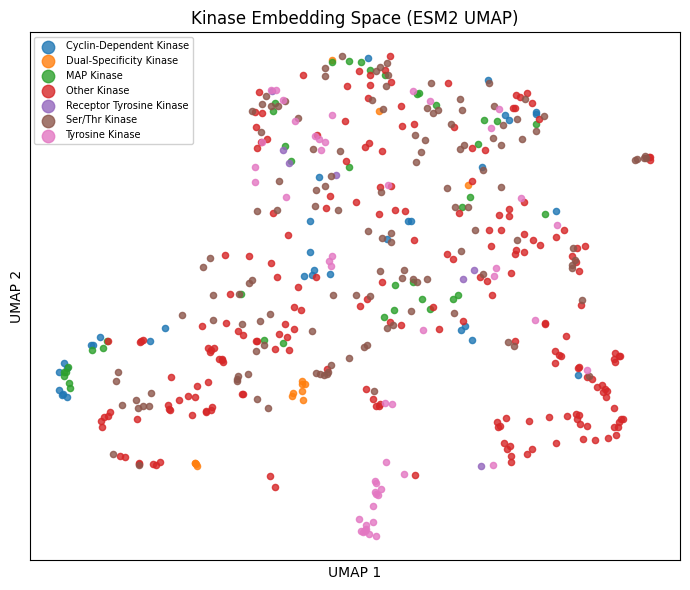

In [19]:
# Figure 2 — Protein embedding UMAP (ESM2, color by kinase subfamily)

def assign_subfamily(target_name):
    n = str(target_name).lower()
    if 'receptor tyrosine' in n or 'receptor-type tyrosine' in n:
        return 'Receptor Tyrosine Kinase'
    if 'tyrosine' in n:
        return 'Tyrosine Kinase'
    if 'serine/threonine' in n or 'serine-threonine' in n:
        return 'Ser/Thr Kinase'
    if 'dual' in n or 'dual-specificity' in n:
        return 'Dual-Specificity Kinase'
    if 'map kinase' in n or 'mitogen' in n:
        return 'MAP Kinase'
    if 'cyclin' in n:
        return 'Cyclin-Dependent Kinase'
    return 'Other Kinase'

uid_to_target = df.groupby(UNIPROT_COL)[TARGET_NAME_COL].first()
uid_list = [u for u in seq_map if u in emb_cache]
prot_emb_matrix = np.stack([emb_cache[u] for u in uid_list])
subfamilies = [assign_subfamily(uid_to_target.get(u, '')) for u in uid_list]

reducer_prot = umap.UMAP(metric='cosine', n_neighbors=15, min_dist=0.1, random_state=42)
prot_umap = reducer_prot.fit_transform(prot_emb_matrix)

palette = sns.color_palette('tab10', n_colors=len(set(subfamilies)))
subfamily_list = sorted(set(subfamilies))
color_map = dict(zip(subfamily_list, palette))

fig, ax = plt.subplots(figsize=(7, 6))
for sf in subfamily_list:
    mask = [s == sf for s in subfamilies]
    ax.scatter(prot_umap[mask, 0], prot_umap[mask, 1],
               c=[color_map[sf]], label=sf, s=20, alpha=0.8, rasterized=True)
ax.legend(fontsize=7, markerscale=2, framealpha=0.9)
ax.set_title('Kinase Embedding Space (ESM2 UMAP)')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_protein_umap.png', dpi=150)
plt.show()

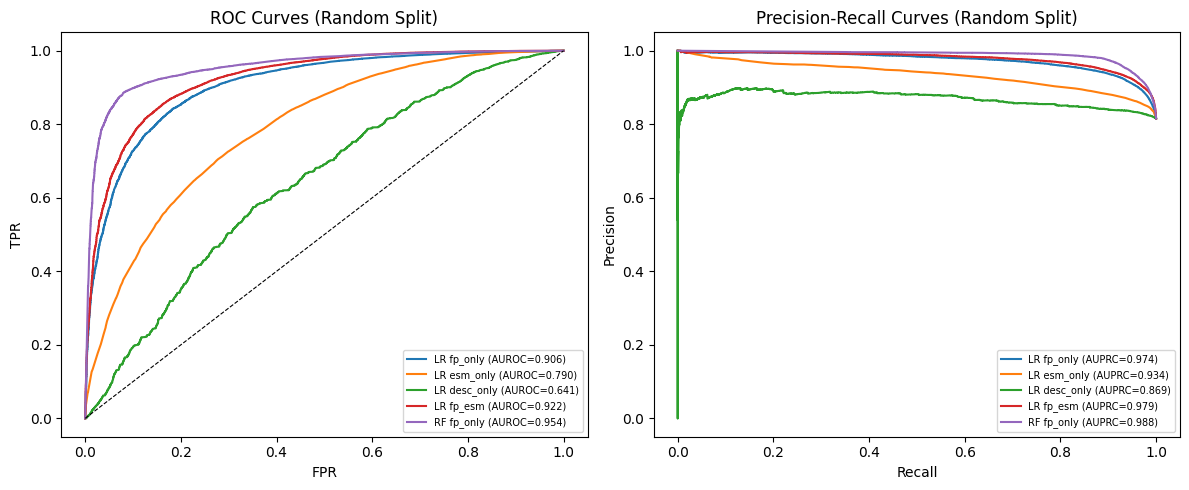

In [20]:
# Figure 3 — ROC + PR curves (random split, all model×feature combos)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

random_models = {k: v for k, v in models.items() if k[2] == 'random'}
palette_fig3 = sns.color_palette('tab10', n_colors=len(random_models))

for (key, model), color in zip(random_models.items(), palette_fig3):
    _, feat_name, _ = key
    X = features[feat_name]
    probs = model.predict_proba(X[idx_test1])[:, 1]
    auroc = roc_auc_score(y[idx_test1], probs)
    auprc = average_precision_score(y[idx_test1], probs)
    label = f"{key[0]} {feat_name} (AUROC={auroc:.3f})"

    fpr, tpr, _ = roc_curve(y[idx_test1], probs)
    axes[0].plot(fpr, tpr, color=color, lw=1.5, label=label)

    prec, rec, _ = precision_recall_curve(y[idx_test1], probs)
    axes[1].plot(rec, prec, color=color, lw=1.5,
                 label=f"{key[0]} {feat_name} (AUPRC={auprc:.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves (Random Split)')
axes[0].legend(fontsize=7)

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves (Random Split)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_roc_pr_curves.png', dpi=150)
plt.show()

Best random-split model: ('RF', 'fp_only', 'random'), AUROC=0.954


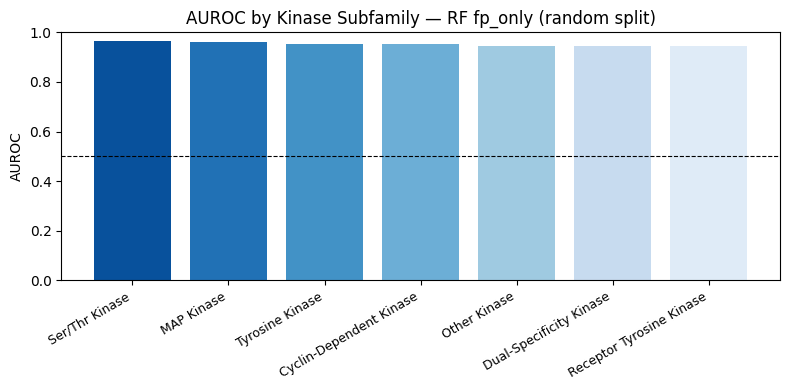

In [21]:
# Figure 4 — AUROC by kinase subfamily (best random-split model)

random_results = results_df[results_df['Split'] == 'random']
best_row = random_results.loc[random_results['AUROC'].idxmax()]
best_key = (best_row['Model'], best_row['Features'], 'random')
best_model = models[best_key]
best_feat = features[best_row['Features']]
print(f"Best random-split model: {best_key}, AUROC={best_row['AUROC']}")

df_test1 = df.iloc[idx_test1].copy()
df_test1['proba'] = best_model.predict_proba(best_feat[idx_test1])[:, 1]
df_test1['subfamily'] = df_test1[TARGET_NAME_COL].map(assign_subfamily)

subfamily_auroc = {}
for sf, grp in df_test1.groupby('subfamily'):
    if grp['label'].nunique() < 2 or len(grp) < 10:
        continue
    subfamily_auroc[sf] = roc_auc_score(grp['label'], grp['proba'])

sf_df = pd.Series(subfamily_auroc).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sf_df.index, sf_df.values, color=sns.color_palette('Blues_r', len(sf_df)))
ax.axhline(0.5, color='k', lw=0.8, ls='--')
ax.set_ylabel('AUROC')
ax.set_title(f'AUROC by Kinase Subfamily — {best_row["Model"]} {best_row["Features"]} (random split)')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_auroc_by_subfamily.png', dpi=150)
plt.show()

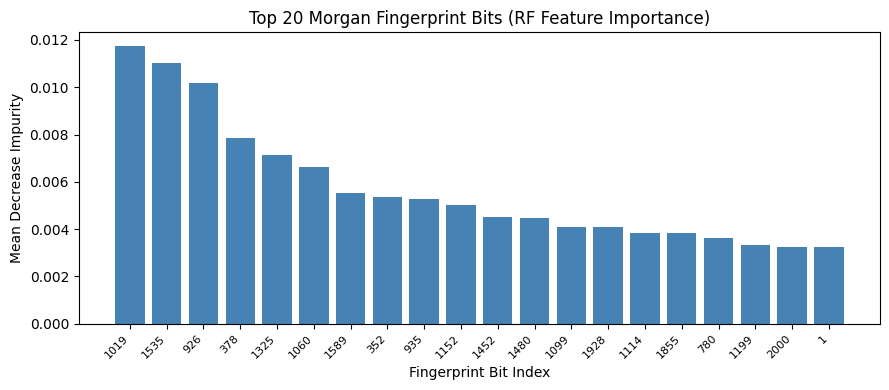

Top 20 bit indices: [1019, 1535, 926, 378, 1325, 1060, 1589, 352, 935, 1152, 1452, 1480, 1099, 1928, 1114, 1855, 780, 1199, 2000, 1]

Top 5 bit → example activating SMILES (first molecule found):
  bit 1019: OC(=O)c1cccc(O)c1C(=O)c1c(O)cc(cc1O)C(=O)O[C@@H]1CCCNC[C@H]1
  bit 1535: Cn1ncc2c(cccc12)-c1cccn2nc(Nc3ccc4CCN(CCc4c3)C(=O)OC(C)(C)C)
  bit 926: Cn1ncc2c(cccc12)-c1cccn2nc(Nc3ccc4CCN(CCc4c3)C(=O)OC(C)(C)C)
  bit 378: Cn1c2ncn(CCO)c(=O)c2c(Nc2ccc(I)cc2F)cc1=O
  bit 1325: OC(=O)c1cccc(O)c1C(=O)c1c(O)cc(cc1O)C(=O)O[C@@H]1CCCNC[C@H]1


In [22]:
# Figure 5 — RF feature importance: top 20 fingerprint bits
from rdkit.Chem import AllChem, Draw

rf_model = models.get(('RF', 'fp_esm', 'random'), models.get(('RF', 'fp_only', 'random')))
importances = rf_model.feature_importances_[:2048]  # first 2048 are FP bits
top20_idx = np.argsort(importances)[::-1][:20]
top20_imp = importances[top20_idx]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(20), top20_imp, color='steelblue')
ax.set_xticks(range(20))
ax.set_xticklabels([str(i) for i in top20_idx], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Fingerprint Bit Index')
ax.set_ylabel('Mean Decrease Impurity')
ax.set_title('Top 20 Morgan Fingerprint Bits (RF Feature Importance)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_rf_feature_importance.png', dpi=150)
plt.show()

print("Top 20 bit indices:", top20_idx.tolist())

# Morgan bit indices are molecule-dependent; decode is approximate.
try:
    from rdkit.Chem import AllChem as rAllChem
    print("\nTop 5 bit → example activating SMILES (first molecule found):")
    for bit in top20_idx[:5]:
        for smi in list(fp_cache.keys())[:5000]:
            arr = fp_cache[smi]
            if arr[bit] == 1:
                print(f"  bit {bit}: {smi[:60]}")
                break
        else:
            print(f"  bit {bit}: no activating molecule found in first 5000")
except Exception as e:
    print(f"Substructure decode skipped: {e}")

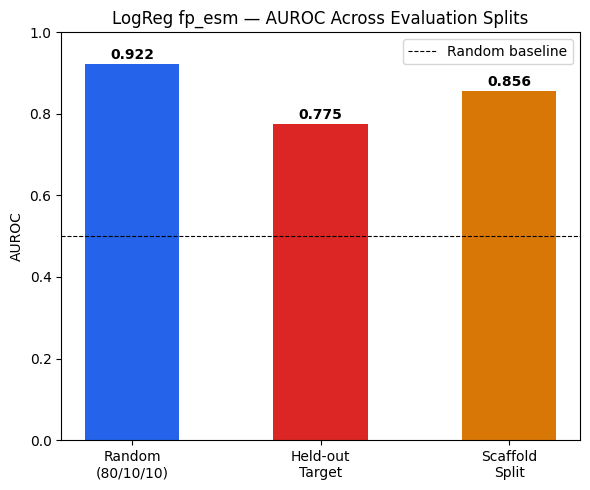

In [23]:
# Figure 6 — Split comparison bar chart (LogReg fp_esm, all 3 splits)

split_labels = ['random', 'target', 'scaffold']
split_display = ['Random\n(80/10/10)', 'Held-out\nTarget', 'Scaffold\nSplit']

lr_fp_esm_rows = results_df[
    (results_df['Model'] == 'LR') & (results_df['Features'] == 'fp_esm')
].set_index('Split')

auroc_vals = [lr_fp_esm_rows.loc[s, 'AUROC'] if s in lr_fp_esm_rows.index else float('nan')
              for s in split_labels]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(split_display, auroc_vals,
              color=['#2563EB', '#DC2626', '#D97706'], width=0.5)
for bar, val in zip(bars, auroc_vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(0.5, color='k', lw=0.8, ls='--', label='Random baseline')
ax.set_ylim(0, 1)
ax.set_ylabel('AUROC')
ax.set_title('LogReg fp_esm — AUROC Across Evaluation Splits')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_split_comparison.png', dpi=150)
plt.show()

## 10. Interpretation

The negative sampling caveat belongs first: affinity-threshold negatives (Ki > 10 μM) are structurally similar to known binders because experimenters disproportionately test compounds they expect to bind; the negative class is not a random draw from chemical space. Performance on a prospective screening task would likely be lower. The truncation flag also applies throughout: 87 of 487 kinase sequences (17.9%) were truncated to 1022 residues before embedding, exceeding the 10% threshold; for multi-domain kinases, this discards C-terminal regulatory or catalytic domains and may degrade embedding quality.

On 97 kinase proteins withheld entirely from training, LR fp_esm achieves AUROC 0.775, a drop of 0.147 from the random split (0.922). The model retains real predictive signal; 0.775 is well above chance. But the gap is real: part of what the random split rewards is learning which drugs tend to co-occur with which specific proteins in the training data, and that pattern does not transfer to unseen kinases.

The scaffold split drop is 0.066 AUROC points (0.856 vs 0.922 random). Morgan fingerprints transfer to novel scaffolds more readily than ESM2 embeddings transfer to novel protein targets. The drug-side drop is the weaker generalization test because ATP-competitive kinase inhibitors share pharmacophoric requirements regardless of scaffold; structural novelty on the drug side is less challenging than target novelty on the protein side. F1 for held-out target and scaffold splits is computed using thresholds selected on the respective training sets; AUROC is the primary cross-split metric.

esm_only achieves AUROC 0.790, and fp_esm outperforms fp_only by +0.016 on the random split. The protein embedding adds real signal: different kinases bind different drug profiles, and ESM2 partially encodes those differences from sequence alone. The gain is modest, bounded by two hardware-forced constraints: the 150M model substitution (640-dim vs the 1280-dim 650M model originally intended) and 17.9% sequence truncation for multi-domain kinases.

desc_only AUROC is 0.641, compared to 0.906 for fp_only. The seven Lipinski descriptors are not competitive. Kinase selectivity is determined by detailed chemical topology, the specific atomic arrangements that engage the ATP-binding site and hinge region, not by bulk drug-likeness properties like molecular weight or hydrogen bond counts.

RF fp_only achieves AUROC 0.954, outperforming LR fp_only (0.906) by 0.048. Morgan fingerprint bits are correlated through shared substructural patterns; joint bit activation encodes binding information a linear model cannot exploit. RF fp_esm could not be evaluated; estimated 14.9 GB RAM with 2.2 GB available was insufficient for 300 trees on 365k × 2688 features.

RF fp_only performance is consistent across kinase subfamilies in the test set (Figure 4). No single kinase class drives the aggregate AUROC, and no class shows systematic failure.

Positive prevalence in this dataset is 372,555 / 456,674 ≈ 0.816. A trivial all-positive classifier achieves AUPRC ≈ 0.82. desc_only AUPRC of 0.869 is only +0.053 above that baseline; discriminative signal is marginal. AUPRC values for stronger models (0.974–0.988) show meaningful gaps from baseline (+0.16) but should not be compared against balanced-dataset benchmarks. AUROC is the interpretable metric at this positive prevalence.